# Two-regime HMM with rolling-dependent Gaussian emissions

This experiment uses **only 1990–2000** S&P 500 price-index levels. It fits on 1990–1999 and visualizes 2000 without using 2000 for selection. Compare 10-, 20-, and 60-trading-day rolling windows. All three candidates have exactly **two regimes** and the same return observations.

Unlike the initialization-only sweep, the lagged rolling mean and volatility enter the **emission parameters on every day**. For state $k$ and day $t$, the conditional return density is

$$
r_t \mid (S_t=k,\mathcal F_{t-1})
\sim N\!\left(a_k+b_k m_{t-1,w},\;c_k^2 v_{t-1,w}^2\right).
$$

Here $m_{t-1,w}$ and $v_{t-1,w}$ are the mean and standard deviation of the previous $w$ returns. The HMM learns $a_k$, $b_k$, $c_k^2$, the initial state distribution, and the transition matrix. The features are known before $r_t$ and change the *fitted density* each day; they are not merely used to seed the optimizer. The model represents a **conditional density for returns given rolling features**, not a joint Gaussian density for all three columns.

Selection is intentionally simple: compare training **AIC and BIC only**. The 2000 plot is descriptive, not a test-set selection metric.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
if not (project_root / "src/flexible_emission_hmm").exists():
    project_root = project_root.parent
if not (project_root / "src/flexible_emission_hmm").exists():
    raise FileNotFoundError("Run from the project root or notebooks directory")
sys.path.insert(0, str(project_root / "src"))

from flexible_emission_hmm.emissions import EmissionModel
from flexible_emission_hmm.feature import daily_log_return, rolling_mean_return, rolling_volatility
from flexible_emission_hmm.hmm import HMM
from flexible_emission_hmm.training import BaumWelchTrainer
from flexible_emission_hmm.validation import as_sequence

DATA_PATH = project_root / "data/processed/sp500_index_price.csv"
OUTPUT_DIR = project_root / "data/artifacts/sp500_two_regime_rolling/1990_1999_train_2000_view"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WINDOWS = (10, 20, 60)
N_STARTS = 4
MAX_ITER = 250
TOL = 1e-3
MIN_RELATIVE_VARIANCE = 0.02
MASTER_SEED = 20261003

data = pd.read_csv(DATA_PATH, parse_dates=["YYYYMMDD"]).sort_values("YYYYMMDD")
prices = data.set_index("YYYYMMDD")["DlyPrcInd"].loc["1990":"2000"]
returns = daily_log_return(prices)
lagged_returns = returns.shift(1)
feature_frames = {
    window: pd.DataFrame({
        "return": returns,
        "rolling_mean": rolling_mean_return(lagged_returns, days=window),
        "rolling_volatility": rolling_volatility(lagged_returns, days=window),
    })
    for window in WINDOWS
}
common_dates = feature_frames[max(WINDOWS)].dropna().index
feature_frames = {window: frame.loc[common_dates] for window, frame in feature_frames.items()}
if any(frame.isna().any().any() for frame in feature_frames.values()):
    raise ValueError("Rolling features must be complete on common dates")
training_dates = common_dates[common_dates.year <= 1999]
evaluation_dates = common_dates[common_dates.year == 2000]
if len(training_dates) == 0 or len(evaluation_dates) == 0:
    raise ValueError("The requested periods are incomplete")
training_returns = feature_frames[10].loc[training_dates, "return"]
center = float(training_returns.mean())
scale = float(training_returns.std(ddof=0))
if not np.isfinite(scale) or scale <= 0:
    raise ValueError("Training returns need positive finite dispersion")
print(f"Common training days: {len(training_dates)}; 2000 days: {len(evaluation_dates)}")
print(f"Dates: {common_dates.min().date()}–{common_dates.max().date()}")

Common training days: 2467; 2000 days: 252
Dates: 1990-03-29–2000-12-29


## Conditional emission and fitting

In standardized units, the notebook estimates

$$
\mu_{k,t}=\alpha_k+\beta_k\bar r_{t-1,w},\qquad
\sigma^2_{k,t}=\rho_k\,s^2_{t-1,w}.
$$

The M-step uses posterior-weighted least squares for $(\alpha_k,\beta_k)$ with weights proportional to $1/s^2_{t-1,w}$, then updates $\rho_k$ from weighted standardized squared residuals. This is the Gaussian conditional-likelihood M-step for fixed rolling covariates. A small lower bound prevents zero state variance. Four deterministic starts per window reduce local-optimum sensitivity; the highest fitted training likelihood is retained.

In [2]:
class RollingConditionalGaussian(EmissionModel):
    def __init__(self, seed, min_relative_variance=MIN_RELATIVE_VARIANCE):
        super().__init__(n_states=2)
        self.seed = seed
        self.min_relative_variance = min_relative_variance
        self.intercepts = None
        self.slopes = None
        self.relative_variances = None

    def initialize(self, X):
        X = as_sequence(X, 3)
        if (X[:, 2] <= 0).any():
            raise ValueError("Lagged rolling volatility must be positive")
        self.n_features = 3
        rng = np.random.default_rng(self.seed)
        self.intercepts = np.quantile(X[:, 0], [0.4, 0.6]) + rng.normal(0, 0.05, 2)
        self.slopes = np.zeros(2)
        self.relative_variances = np.array([0.5, 2.0]) * rng.uniform(0.85, 1.15, 2)

    def conditional_parameters(self, X):
        X = as_sequence(X, 3)
        means = self.intercepts[None, :] + X[:, 1, None] * self.slopes[None, :]
        variances = X[:, 2, None] ** 2 * self.relative_variances[None, :]
        return means, variances

    def log_prob(self, X):
        X = as_sequence(X, 3)
        means, variances = self.conditional_parameters(X)
        return -0.5 * (
            np.log(2 * np.pi * variances)
            + (X[:, 0, None] - means) ** 2 / variances
        )

    def m_step(self, X, responsibilities):
        X = as_sequence(X, 3)
        weights = np.asarray(responsibilities, dtype=float)
        design = np.column_stack([np.ones(len(X)), X[:, 1]])
        volatility_squared = X[:, 2] ** 2
        for state in range(2):
            mass = float(weights[:, state].sum())
            if mass <= np.finfo(float).eps:
                continue
            weighted_design = np.sqrt(weights[:, state] / volatility_squared)
            coefficients = np.linalg.lstsq(
                design * weighted_design[:, None],
                X[:, 0] * weighted_design,
                rcond=None,
            )[0]
            residuals = X[:, 0] - design @ coefficients
            relative_variance = float(
                np.sum(weights[:, state] * residuals**2 / volatility_squared) / mass
            )
            self.intercepts[state], self.slopes[state] = coefficients
            self.relative_variances[state] = max(
                relative_variance, self.min_relative_variance
            )


def model_matrix(frame):
    return np.column_stack([
        (frame["return"].to_numpy() - center) / scale,
        (frame["rolling_mean"].to_numpy() - center) / scale,
        frame["rolling_volatility"].to_numpy() / scale,
    ])


fitted = {}
attempt_rows = []
metric_rows = []
for window in WINDOWS:
    train_matrix = model_matrix(feature_frames[window].loc[training_dates])
    best = None
    best_likelihood = -np.inf
    for start in range(N_STARTS):
        seed = MASTER_SEED + 100 * window + start
        trainer = BaumWelchTrainer(max_iter=MAX_ITER, tol=TOL)
        model = HMM(RollingConditionalGaussian(seed), trainer=trainer)
        model.fit(train_matrix)
        likelihood_z = float(model.history[-1])
        attempt_rows.append({
            "window": window, "seed": seed, "train_log_likelihood_z": likelihood_z,
            "updates": trainer.n_iter, "converged": trainer.converged,
        })
        if likelihood_z > best_likelihood:
            best, best_likelihood = model, likelihood_z
    fitted[window] = best
    log_likelihood = best_likelihood - len(train_matrix) * np.log(scale)
    parameters = 9
    metric_rows.append({
        "window": window, "train_days": len(train_matrix), "parameters": parameters,
        "train_log_likelihood": log_likelihood,
        "aic": 2 * parameters - 2 * log_likelihood,
        "bic": parameters * np.log(len(train_matrix)) - 2 * log_likelihood,
        "updates": best.trainer.n_iter, "converged": best.trainer.converged,
    })
attempts = pd.DataFrame(attempt_rows)
metrics = pd.DataFrame(metric_rows).set_index("window")
selected_window = int(metrics["bic"].idxmin())
print(metrics.round(3).to_string())
print(f"BIC-selected rolling window: {selected_window} days")

        train_days  parameters  train_log_likelihood        aic        bic  updates  converged
window                                                                                        
10            2467           9              8402.630 -16787.260 -16734.963      183       True
20            2467           9              8445.694 -16873.389 -16821.092      250      False
60            2467           9              8459.443 -16900.886 -16848.589      221       True
BIC-selected rolling window: 60 days


## AIC, BIC, and what the rolling terms learned

For two states there are $1$ initial-state, $2$ transition, and $6$ emission parameters: **9 total**. Every window uses the same return dates and parameter count, so AIC and BIC are comparable here; the three rolling windows are alternative fixed covariate constructions. AIC/BIC do **not** account for having inspected several windows.

The daily conditional mean and standard deviation below come from the fitted coefficients and that day's lagged rolling features. Their movement shows that rolling features remain inside the model *after* training.

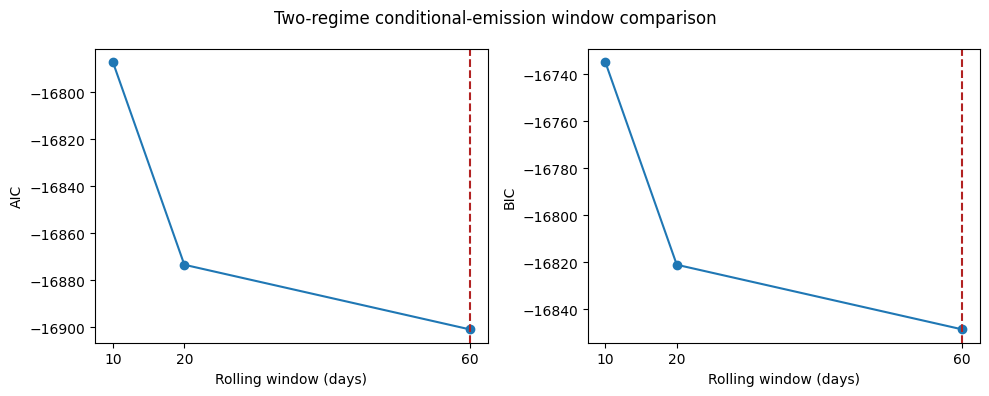

 window  state  intercept_z  rolling_mean_slope  relative_variance  relative_sd
     10      0       0.0389             -0.3884             0.6424       0.8015
     10      1      -0.0893              0.4770             3.1689       1.7801
     20      0       0.0408             -0.5583             0.5355       0.7318
     20      1      -0.0980              0.7656             2.2491       1.4997
     60      0       0.0427             -0.2632             0.8022       0.8957
     60      1      -0.5099             -0.3005             3.5427       1.8822


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(WINDOWS, metrics.loc[list(WINDOWS), "aic"], marker="o")
axes[0].axvline(selected_window, color="firebrick", linestyle="--")
axes[0].set(xlabel="Rolling window (days)", ylabel="AIC", xticks=WINDOWS)
axes[1].plot(WINDOWS, metrics.loc[list(WINDOWS), "bic"], marker="o")
axes[1].axvline(selected_window, color="firebrick", linestyle="--")
axes[1].set(xlabel="Rolling window (days)", ylabel="BIC", xticks=WINDOWS)
fig.suptitle("Two-regime conditional-emission window comparison")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "aic_bic_windows.png", dpi=160)
plt.show()

parameter_rows = []
for window in WINDOWS:
    emission = fitted[window].emission
    for state in range(2):
        parameter_rows.append({
            "window": window, "state": state,
            "intercept_z": emission.intercepts[state],
            "rolling_mean_slope": emission.slopes[state],
            "relative_variance": emission.relative_variances[state],
            "relative_sd": np.sqrt(emission.relative_variances[state]),
        })
parameters = pd.DataFrame(parameter_rows)
print(parameters.round(4).to_string(index=False))

## 2000 filtered phase and time-varying emission parameters

The plot uses the BIC-selected window, with all parameters fitted on 1990–1999. The 2000 state curve is **0 = lower conditional variance multiplier, 1 = higher multiplier**, assigned by the largest filtered state probability *after* each day's return. It is not a probability of switching. The conditional mean and standard-deviation lines are determined by the fitted state coefficients **and the prior rolling features**; no 2000 refitting occurs.

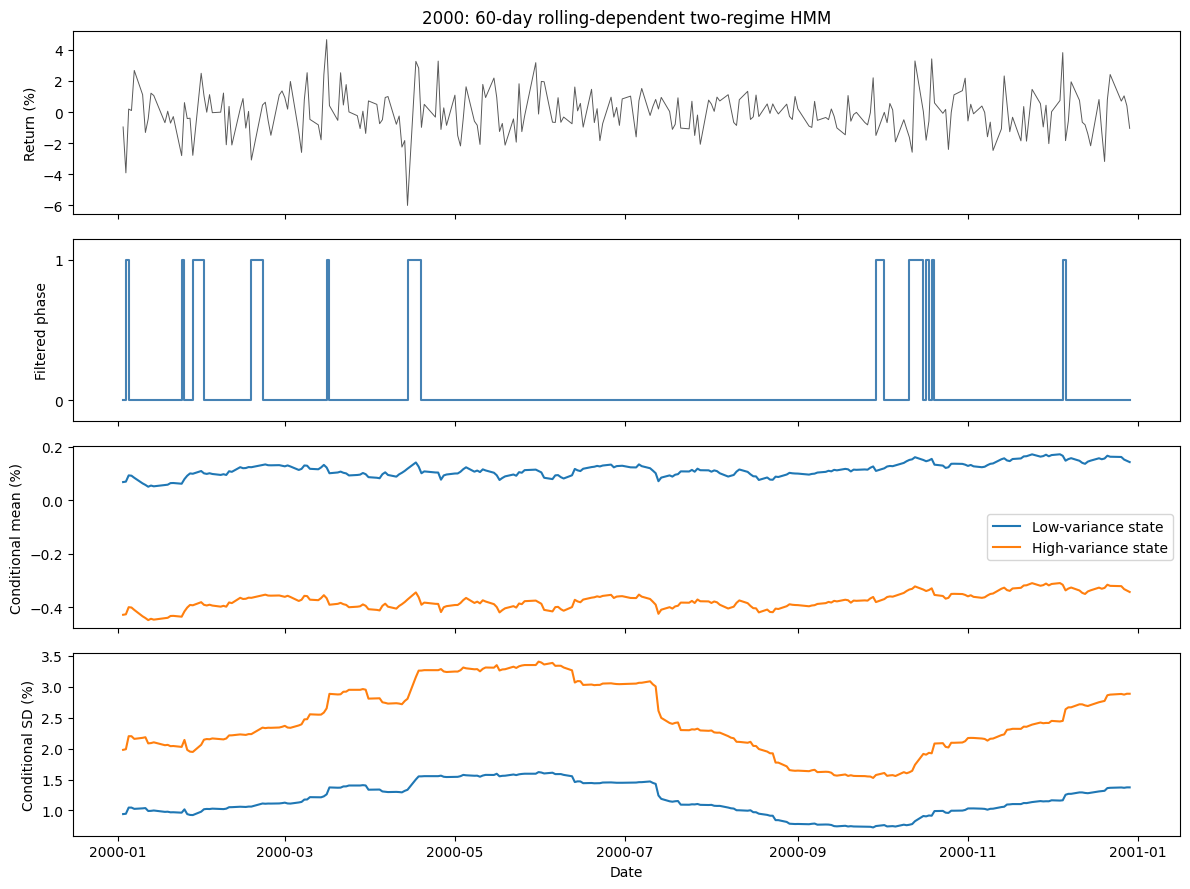

In [4]:
selected_model = fitted[selected_window]
selected_frame = feature_frames[selected_window]
train_matrix = model_matrix(selected_frame.loc[training_dates])
test_matrix = model_matrix(selected_frame.loc[evaluation_dates])
_, train_filtered, _ = selected_model.filter(train_matrix)
initial_prior = train_filtered[-1] @ selected_model.states.transitions
predicted, filtered, _ = selected_model.filter(test_matrix, initial_prior=initial_prior)
emission = selected_model.emission
order = np.argsort(emission.relative_variances)
low_state, high_state = order
phase = (np.argmax(filtered, axis=1) == high_state).astype(int)
means_z, variances_z = emission.conditional_parameters(test_matrix)
means_pct = 100 * (center + scale * means_z[:, order])
sds_pct = 100 * scale * np.sqrt(variances_z[:, order])

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(evaluation_dates, 100 * selected_frame.loc[evaluation_dates, "return"],
             color="0.35", linewidth=0.7)
axes[0].set(ylabel="Return (%)", title=f"2000: {selected_window}-day rolling-dependent two-regime HMM")
axes[1].step(evaluation_dates, phase, where="post", color="steelblue")
axes[1].set(ylabel="Filtered phase", yticks=[0, 1], ylim=(-0.15, 1.15))
for state, label in enumerate(("Low-variance state", "High-variance state")):
    axes[2].plot(evaluation_dates, means_pct[:, state], label=label)
    axes[3].plot(evaluation_dates, sds_pct[:, state], label=label)
axes[2].set_ylabel("Conditional mean (%)")
axes[3].set(ylabel="Conditional SD (%)", xlabel="Date")
axes[2].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "rolling_conditional_phases_2000.png", dpi=160)
plt.show()

## Saved outputs

The artifact folder contains AIC/BIC, fit attempts, state-specific conditional-emission coefficients, the 2000 phase and conditional-parameter trajectories, and a manifest with transition and start probabilities. All input prices and features used here lie within 1990–2000.

In [5]:
attempts.to_csv(OUTPUT_DIR / "fit_attempts.csv", index=False)
metrics.to_csv(OUTPUT_DIR / "aic_bic.csv")
parameters.to_csv(OUTPUT_DIR / "conditional_emission_parameters.csv", index=False)
pd.DataFrame({
    "date": evaluation_dates, "log_return": selected_frame.loc[evaluation_dates, "return"].to_numpy(),
    "filtered_phase": phase,
    "low_state_mean_pct": means_pct[:, 0], "high_state_mean_pct": means_pct[:, 1],
    "low_state_sd_pct": sds_pct[:, 0], "high_state_sd_pct": sds_pct[:, 1],
}).to_csv(OUTPUT_DIR / "daily_2000.csv", index=False)
manifest = {
    "data_path": str(DATA_PATH.relative_to(project_root)),
    "period": "1990–2000 only",
    "training_years": [1990, 1999],
    "visualization_year": 2000,
    "windows": list(WINDOWS),
    "selected_window_by_bic": selected_window,
    "n_starts": N_STARTS, "max_iter": MAX_ITER, "tol": TOL,
    "training_center": center, "training_scale": scale,
    "models": {},
}
for window in WINDOWS:
    model = fitted[window]
    manifest["models"][str(window)] = {
        "start_probabilities": model.states.start.tolist(),
        "transition_matrix": model.states.transitions.tolist(),
        "intercepts_z": model.emission.intercepts.tolist(),
        "rolling_mean_slopes": model.emission.slopes.tolist(),
        "relative_variances": model.emission.relative_variances.tolist(),
        "training_log_likelihood_z": float(model.history[-1]),
    }
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2))
print(f"Saved rolling-emission experiment to {OUTPUT_DIR}")

Saved rolling-emission experiment to /Users/yushe/Desktop/UNI/FALL26/CSCD94/FlexibleEmissionHMM/data/artifacts/sp500_two_regime_rolling/1990_1999_train_2000_view
